# Linear Discriminant Analysis with Clustering

This notebook implements LDA classifier with various clustering strategies to predict disease infection rates in Africa.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, 
    confusion_matrix, classification_report, silhouette_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Load and Preprocess Data

In [2]:
# Load data
df = pd.read_csv('../../data/processed/cleaned_disease_dataset_2015landuse.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (473, 17)

Columns: ['year', 'country', 'admin', 'infection_rate', 'max_temperature', 'min_temperature', 'avg_temperature', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse', 'missing_ratio']


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


In [3]:
# Check infection_rate statistics
print("Infection Rate Statistics:")
print(df['infection_rate'].describe())
print(f"\nNumber of zeros: {(df['infection_rate'] == 0).sum()}")

Infection Rate Statistics:
count    473.000000
mean       5.420915
std        6.599666
min        0.000000
25%        1.075992
50%        2.145923
75%        7.500000
max       27.073403
Name: infection_rate, dtype: float64

Number of zeros: 2


## Data Preprocessing

Apply the same preprocessing used in previous best model:
1. Remove Buffa column (all zeros)
2. Log transform livestock features
3. Keep only min_temperature (remove max and avg)
4. StandardScaler for feature scaling

In [4]:
# Create a copy for preprocessing
df_processed = df.copy()

# Remove Buffa column if exists
if 'Buffa' in df_processed.columns:
    df_processed = df_processed.drop('Buffa', axis=1)
    print("Removed Buffa column")

# Log transform livestock columns
livestock_cols = ['Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
for col in livestock_cols:
    if col in df_processed.columns:
        df_processed[col] = np.log1p(df_processed[col])
print(f"Log-transformed livestock columns: {livestock_cols}")

# Keep only min_temperature
temp_cols_to_drop = ['max_temperature', 'avg_temperature']
df_processed = df_processed.drop([col for col in temp_cols_to_drop if col in df_processed.columns], axis=1)
print(f"Removed temperature columns: {temp_cols_to_drop}")

print(f"\nProcessed dataset shape: {df_processed.shape}")
print(f"Remaining columns: {df_processed.columns.tolist()}")

Removed Buffa column
Log-transformed livestock columns: ['Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
Removed temperature columns: ['max_temperature', 'avg_temperature']

Processed dataset shape: (473, 14)
Remaining columns: ['year', 'country', 'admin', 'infection_rate', 'min_temperature', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse', 'missing_ratio']


In [5]:
# Separate features and target
# Exclude key columns (year, country, admin) and target (infection_rate)
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'

feature_cols = [col for col in df_processed.columns if col not in key_cols + [target_col]]
X = df_processed[feature_cols]
y = df_processed[target_col]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature columns (10): ['min_temperature', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse', 'missing_ratio']

X shape: (473, 10)
y shape: (473,)


## Helper Functions

In [6]:
def evaluate_lda_model(X_train, X_test, y_train, y_test, model_name="LDA"):
    """
    Train LDA model and evaluate performance
    
    Returns: dict with all evaluation metrics
    """
    # Train LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, y_train)
    
    # Predictions
    y_pred = lda.predict(X_test)
    
    # Metrics
    test_acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Cross-validation on training set
    cv_scores = cross_val_score(lda, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    results = {
        'model_name': model_name,
        'test_acc': test_acc,
        'balanced_acc': balanced_acc,
        'f1_macro': f1_macro,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }
    
    return results

def print_results(results):
    """
    Print evaluation results in a formatted way
    """
    print(f"\n{'='*60}")
    print(f"Model: {results['model_name']}")
    print(f"{'='*60}")
    print(f"Test Accuracy:      {results['test_acc']*100:.2f}%")
    print(f"Balanced Accuracy:  {results['balanced_acc']*100:.2f}%")
    print(f"F1-Score (macro):   {results['f1_macro']*100:.2f}%")
    print(f"CV Mean Accuracy:   {results['cv_mean']*100:.2f}%")
    print(f"CV Std:             {results['cv_std']*100:.2f}%")
    print(f"{'='*60}\n")

def plot_confusion_matrix(cm, class_names, title):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def analyze_clusters(y, labels, method_name):
    """
    Analyze cluster quality and distribution
    """
    print(f"\n{'-'*60}")
    print(f"Cluster Analysis: {method_name}")
    print(f"{'-'*60}")
    
    # Class distribution
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nClass Distribution:")
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples ({count/len(labels)*100:.2f}%)")
    
    # Infection rate statistics per class
    print(f"\nInfection Rate Statistics per Class:")
    for cls in unique:
        mask = labels == cls
        cls_infections = y[mask]
        print(f"  Class {cls}: Mean={cls_infections.mean():.2f}, "
              f"Std={cls_infections.std():.2f}, "
              f"Range=[{cls_infections.min():.2f}, {cls_infections.max():.2f}]")
    
    print(f"{'-'*60}\n")

## Train-Test Split and Scaling

In [7]:
# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")

Training set size: 378
Test set size: 95

Features scaled using StandardScaler


## Experiment 1: K-means with Different k Values

Compare clustering performance with k=2, 3, 4, 5


############################################################
Experiment 1-2: K-means with k=2
############################################################

------------------------------------------------------------
Cluster Analysis: K-means k=2
------------------------------------------------------------

Class Distribution:
  Class 0: 165 samples (43.65%)
  Class 1: 213 samples (56.35%)

Infection Rate Statistics per Class:
  Class 0: Mean=5.98, Std=5.90, Range=[0.26, 24.24]
  Class 1: Mean=5.17, Std=7.23, Range=[0.00, 27.07]
------------------------------------------------------------

Silhouette Score: 0.2286

Model: E1-2: K-means k=2
Test Accuracy:      90.53%
Balanced Accuracy:  90.68%
F1-Score (macro):   90.52%
CV Mean Accuracy:   94.18%
CV Std:             1.79%



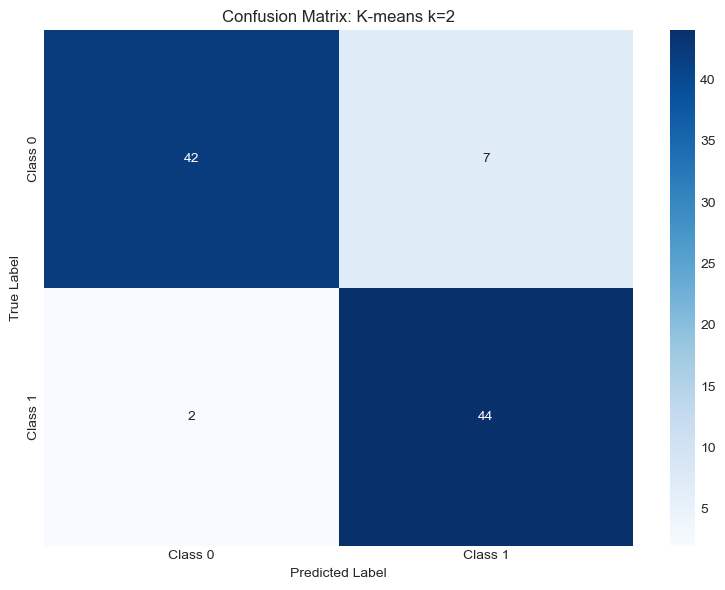


############################################################
Experiment 1-3: K-means with k=3
############################################################

------------------------------------------------------------
Cluster Analysis: K-means k=3
------------------------------------------------------------

Class Distribution:
  Class 0: 115 samples (30.42%)
  Class 1: 105 samples (27.78%)
  Class 2: 158 samples (41.80%)

Infection Rate Statistics per Class:
  Class 0: Mean=6.15, Std=8.75, Range=[0.00, 27.07]
  Class 1: Mean=3.50, Std=4.16, Range=[0.30, 23.40]
  Class 2: Mean=6.40, Std=6.03, Range=[0.41, 24.24]
------------------------------------------------------------

Silhouette Score: 0.2607

Model: E1-3: K-means k=3
Test Accuracy:      95.79%
Balanced Accuracy:  96.68%
F1-Score (macro):   95.95%
CV Mean Accuracy:   95.77%
CV Std:             2.93%



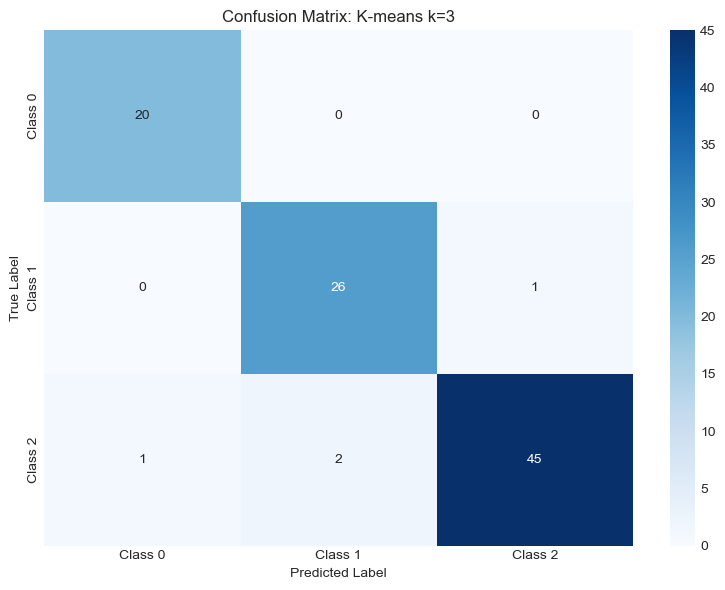


############################################################
Experiment 1-4: K-means with k=4
############################################################

------------------------------------------------------------
Cluster Analysis: K-means k=4
------------------------------------------------------------

Class Distribution:
  Class 0: 68 samples (17.99%)
  Class 1: 146 samples (38.62%)
  Class 2: 111 samples (29.37%)
  Class 3: 53 samples (14.02%)

Infection Rate Statistics per Class:
  Class 0: Mean=4.03, Std=4.35, Range=[0.30, 17.92]
  Class 1: Mean=3.14, Std=4.76, Range=[0.00, 26.89]
  Class 2: Mean=6.99, Std=6.26, Range=[0.41, 24.24]
  Class 3: Mean=10.92, Std=9.94, Range=[0.14, 27.07]
------------------------------------------------------------

Silhouette Score: 0.2509

Model: E1-4: K-means k=4
Test Accuracy:      90.53%
Balanced Accuracy:  90.79%
F1-Score (macro):   89.80%
CV Mean Accuracy:   96.81%
CV Std:             2.75%



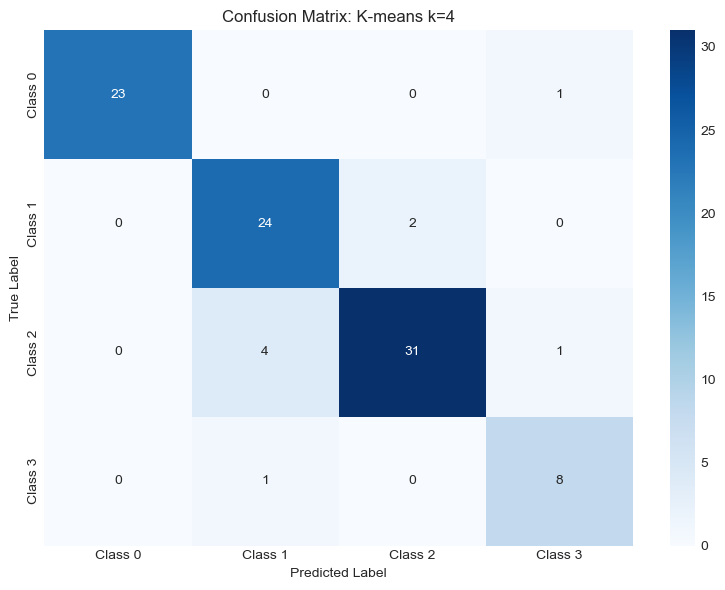


############################################################
Experiment 1-5: K-means with k=5
############################################################

------------------------------------------------------------
Cluster Analysis: K-means k=5
------------------------------------------------------------

Class Distribution:
  Class 0: 77 samples (20.37%)
  Class 1: 29 samples (7.67%)
  Class 2: 109 samples (28.84%)
  Class 3: 21 samples (5.56%)
  Class 4: 142 samples (37.57%)

Infection Rate Statistics per Class:
  Class 0: Mean=3.78, Std=4.16, Range=[0.30, 17.92]
  Class 1: Mean=19.15, Std=5.54, Range=[3.30, 27.07]
  Class 2: Mean=7.10, Std=6.27, Range=[0.41, 24.24]
  Class 3: Mean=1.07, Std=0.70, Range=[0.14, 2.82]
  Class 4: Mean=3.13, Std=4.84, Range=[0.00, 26.89]
------------------------------------------------------------

Silhouette Score: 0.2910

Model: E1-5: K-means k=5
Test Accuracy:      91.58%
Balanced Accuracy:  94.88%
F1-Score (macro):   92.75%
CV Mean Accuracy:   96.

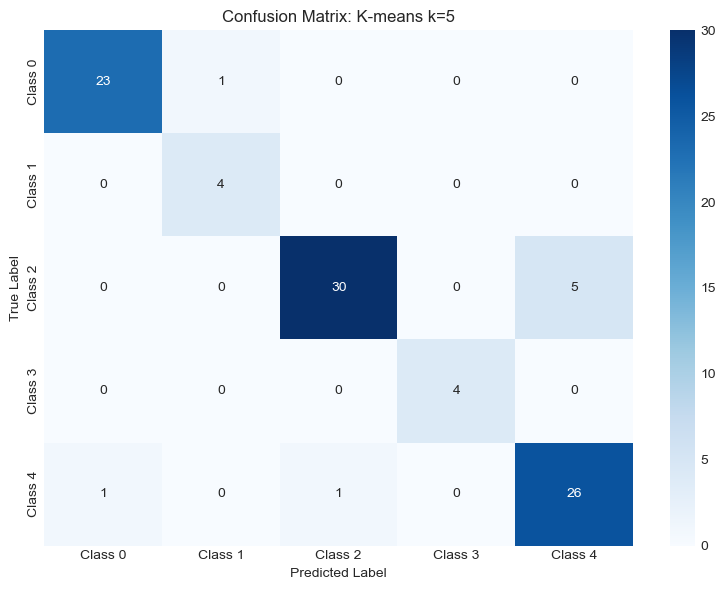

In [8]:
# Store results for comparison
exp1_results = []

k_values = [2, 3, 4, 5]

for k in k_values:
    print(f"\n{'#'*60}")
    print(f"Experiment 1-{k}: K-means with k={k}")
    print(f"{'#'*60}")
    
    # Clustering on training data
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_labels = kmeans.fit_predict(X_train_scaled)
    test_labels = kmeans.predict(X_test_scaled)
    
    # Analyze clusters
    analyze_clusters(y_train.values, train_labels, f"K-means k={k}")
    
    # Calculate silhouette score
    sil_score = silhouette_score(X_train_scaled, train_labels)
    print(f"Silhouette Score: {sil_score:.4f}")
    
    # Train and evaluate LDA
    results = evaluate_lda_model(
        X_train_scaled, X_test_scaled, 
        train_labels, test_labels,
        model_name=f"E1-{k}: K-means k={k}"
    )
    results['silhouette_score'] = sil_score
    results['k'] = k
    
    print_results(results)
    exp1_results.append(results)
    
    # Plot confusion matrix
    class_names = [f"Class {i}" for i in range(k)]
    plot_confusion_matrix(results['confusion_matrix'], class_names, 
                         f"Confusion Matrix: K-means k={k}")

## Experiment 1: Results Summary

In [24]:
# Create summary dataframe
exp1_summary = pd.DataFrame([
    {
        'k': r['k'],
        'Test Acc (%)': f"{r['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{r['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{r['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{r['cv_mean']*100:.2f}",
        'CV Std (%)': f"{r['cv_std']*100:.2f}",
        'Silhouette': f"{r['silhouette_score']:.4f}"
    }
    for r in exp1_results
])

print("\nExperiment 1 Summary: K-means with Different k")
print("="*80)
print(exp1_summary.to_string(index=False))
print("="*80)


Experiment 1 Summary: K-means with Different k
 k Test Acc (%) Balanced Acc (%) F1-macro (%) CV Mean (%) CV Std (%) Silhouette
 2        90.53            90.68        90.52       94.18       1.79     0.2286
 3        95.79            96.68        95.95       95.77       2.93     0.2607
 4        90.53            90.79        89.80       96.81       2.75     0.2509
 5        91.58            94.88        92.75       96.02       3.48     0.2910


## Experiment 2: Alternative Clustering Methods

Fix k=3 and compare:
- K-means
- Gaussian Mixture Model (GMM)
- Quantile-based (tertile)
- Custom threshold

In [10]:
# Store results for comparison
exp2_results = []
k_fixed = 3

### E2-1: K-means (Baseline)


############################################################
Experiment 2-1: K-means (Baseline)
############################################################

------------------------------------------------------------
Cluster Analysis: K-means k=3
------------------------------------------------------------

Class Distribution:
  Class 0: 115 samples (30.42%)
  Class 1: 105 samples (27.78%)
  Class 2: 158 samples (41.80%)

Infection Rate Statistics per Class:
  Class 0: Mean=6.15, Std=8.75, Range=[0.00, 27.07]
  Class 1: Mean=3.50, Std=4.16, Range=[0.30, 23.40]
  Class 2: Mean=6.40, Std=6.03, Range=[0.41, 24.24]
------------------------------------------------------------

Silhouette Score: 0.2607

Model: E2-1: K-means
Test Accuracy:      95.79%
Balanced Accuracy:  96.68%
F1-Score (macro):   95.95%
CV Mean Accuracy:   95.77%
CV Std:             2.93%



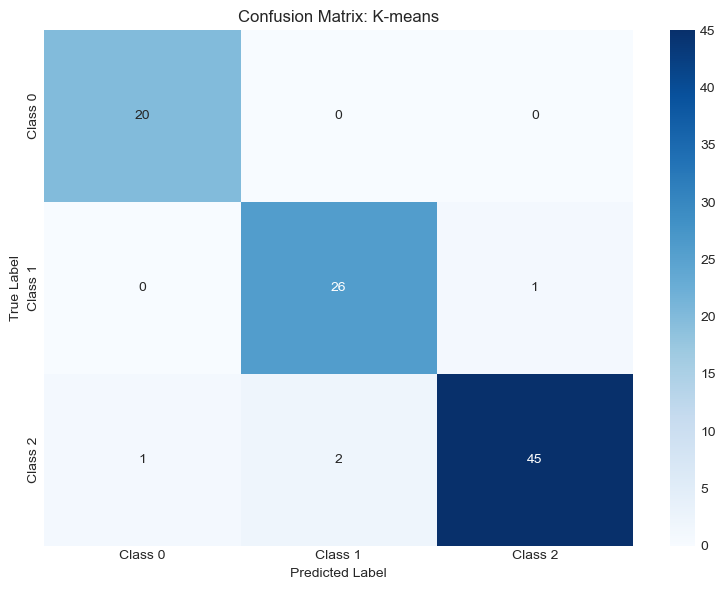

In [11]:
print(f"\n{'#'*60}")
print(f"Experiment 2-1: K-means (Baseline)")
print(f"{'#'*60}")

# K-means clustering
kmeans = KMeans(n_clusters=k_fixed, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_scaled)
test_labels = kmeans.predict(X_test_scaled)

analyze_clusters(y_train.values, train_labels, "K-means k=3")
sil_score = silhouette_score(X_train_scaled, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_scaled, X_test_scaled, 
    train_labels, test_labels,
    model_name="E2-1: K-means"
)
results['silhouette_score'] = sil_score
results['method'] = 'K-means'

print_results(results)
exp2_results.append(results)

class_names = [f"Class {i}" for i in range(k_fixed)]
plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: K-means")

### E2-2: Gaussian Mixture Model (GMM)


############################################################
Experiment 2-2: Gaussian Mixture Model (GMM)
############################################################

------------------------------------------------------------
Cluster Analysis: GMM k=3
------------------------------------------------------------

Class Distribution:
  Class 0: 146 samples (38.62%)
  Class 1: 33 samples (8.73%)
  Class 2: 199 samples (52.65%)

Infection Rate Statistics per Class:
  Class 0: Mean=5.93, Std=6.13, Range=[0.00, 26.89]
  Class 1: Mean=17.51, Std=7.50, Range=[0.28, 27.07]
  Class 2: Mean=3.24, Std=4.37, Range=[0.00, 24.24]
------------------------------------------------------------

Silhouette Score: 0.1254

Model: E2-2: GMM
Test Accuracy:      89.47%
Balanced Accuracy:  92.61%
F1-Score (macro):   92.60%
CV Mean Accuracy:   84.91%
CV Std:             3.24%



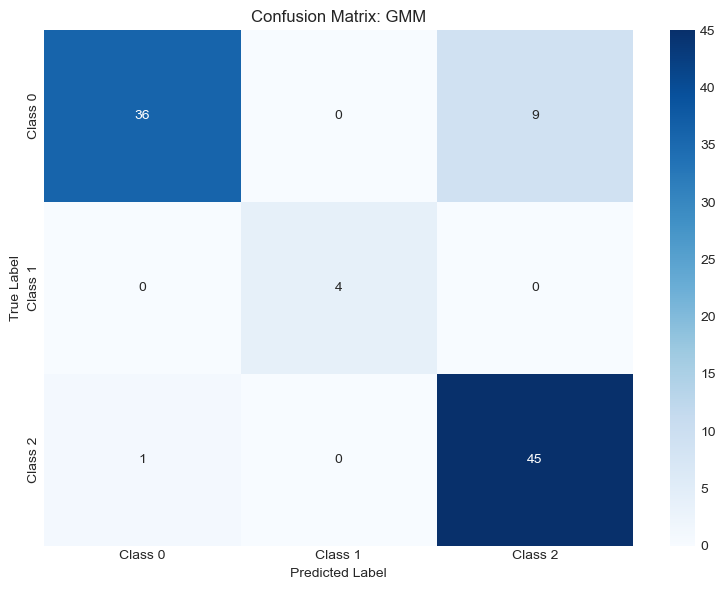

In [12]:
print(f"\n{'#'*60}")
print(f"Experiment 2-2: Gaussian Mixture Model (GMM)")
print(f"{'#'*60}")

# GMM clustering
gmm = GaussianMixture(n_components=k_fixed, random_state=42)
train_labels = gmm.fit_predict(X_train_scaled)
test_labels = gmm.predict(X_test_scaled)

analyze_clusters(y_train.values, train_labels, "GMM k=3")
sil_score = silhouette_score(X_train_scaled, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_scaled, X_test_scaled, 
    train_labels, test_labels,
    model_name="E2-2: GMM"
)
results['silhouette_score'] = sil_score
results['method'] = 'GMM'

print_results(results)
exp2_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: GMM")

### E2-3: Quantile-based (Tertile)


############################################################
Experiment 2-3: Quantile-based (Tertile)
############################################################
33rd percentile: 1.39
66th percentile: 4.28

------------------------------------------------------------
Cluster Analysis: Quantile-based (Tertile)
------------------------------------------------------------

Class Distribution:
  Class 0: 125 samples (33.07%)
  Class 1: 124 samples (32.80%)
  Class 2: 129 samples (34.13%)

Infection Rate Statistics per Class:
  Class 0: Mean=0.77, Std=0.37, Range=[0.00, 1.38]
  Class 1: Mean=2.36, Std=0.78, Range=[1.40, 4.21]
  Class 2: Mean=13.17, Std=6.38, Range=[4.29, 27.07]
------------------------------------------------------------

Silhouette Score: 0.0258

Model: E2-3: Quantile-based
Test Accuracy:      65.26%
Balanced Accuracy:  65.37%
F1-Score (macro):   64.99%
CV Mean Accuracy:   68.24%
CV Std:             5.22%



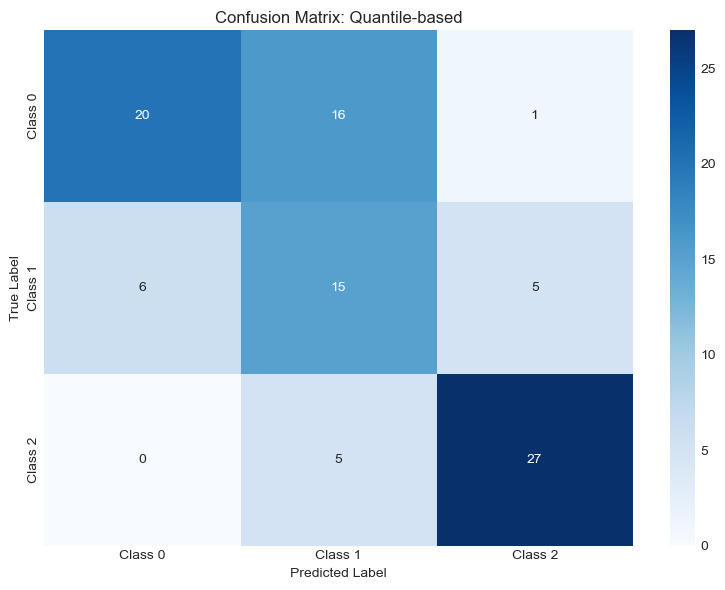

In [13]:
print(f"\n{'#'*60}")
print(f"Experiment 2-3: Quantile-based (Tertile)")
print(f"{'#'*60}")

# Calculate quantiles on training data
q33 = y_train.quantile(0.33)
q66 = y_train.quantile(0.66)
print(f"33rd percentile: {q33:.2f}")
print(f"66th percentile: {q66:.2f}")

# Create labels based on quantiles
train_labels = pd.cut(y_train, bins=[-np.inf, q33, q66, np.inf], labels=[0, 1, 2]).astype(int).values
test_labels = pd.cut(y_test, bins=[-np.inf, q33, q66, np.inf], labels=[0, 1, 2]).astype(int).values

analyze_clusters(y_train.values, train_labels, "Quantile-based (Tertile)")
sil_score = silhouette_score(X_train_scaled, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_scaled, X_test_scaled, 
    train_labels, test_labels,
    model_name="E2-3: Quantile-based"
)
results['silhouette_score'] = sil_score
results['method'] = 'Quantile'

print_results(results)
exp2_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: Quantile-based")

### E2-4: Custom Threshold (Domain-based)


############################################################
Experiment 2-4: Custom Threshold (Domain-based)
############################################################
Thresholds: [0-2.0), [2.0-7.5), [7.5-27]

------------------------------------------------------------
Cluster Analysis: Custom Threshold
------------------------------------------------------------

Class Distribution:
  Class 0: 182 samples (48.15%)
  Class 1: 102 samples (26.98%)
  Class 2: 94 samples (24.87%)

Infection Rate Statistics per Class:
  Class 0: Mean=1.06, Std=0.54, Range=[0.00, 1.97]
  Class 1: Mean=3.84, Std=1.50, Range=[2.01, 7.50]
  Class 2: Mean=15.98, Std=5.14, Range=[7.56, 27.07]
------------------------------------------------------------

Silhouette Score: 0.0380

Model: E2-4: Custom Threshold
Test Accuracy:      67.37%
Balanced Accuracy:  65.48%
F1-Score (macro):   65.27%
CV Mean Accuracy:   69.02%
CV Std:             7.55%



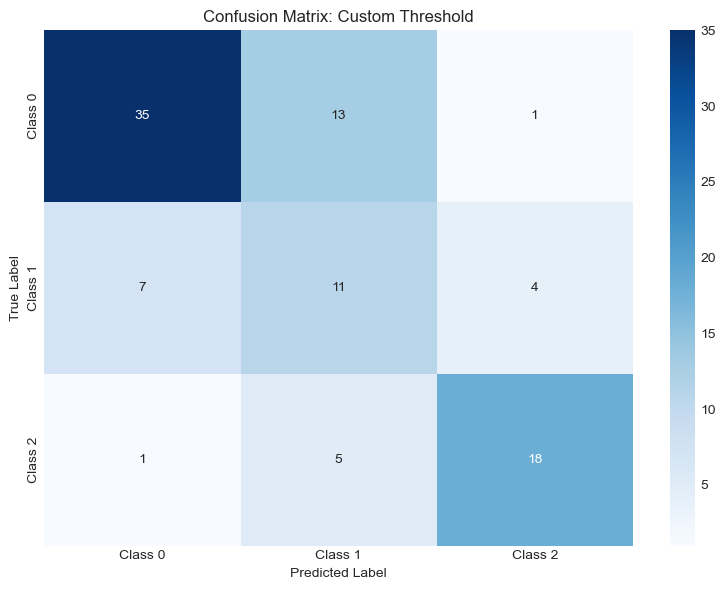

In [14]:
print(f"\n{'#'*60}")
print(f"Experiment 2-4: Custom Threshold (Domain-based)")
print(f"{'#'*60}")

# Define custom thresholds based on domain knowledge
# Low: [0-2), Medium: [2-7.5), High: [7.5-27]
threshold1 = 2.0
threshold2 = 7.5
print(f"Thresholds: [0-{threshold1}), [{threshold1}-{threshold2}), [{threshold2}-27]")

# Create labels
train_labels = pd.cut(y_train, bins=[-np.inf, threshold1, threshold2, np.inf], 
                      labels=[0, 1, 2]).astype(int).values
test_labels = pd.cut(y_test, bins=[-np.inf, threshold1, threshold2, np.inf], 
                     labels=[0, 1, 2]).astype(int).values

analyze_clusters(y_train.values, train_labels, "Custom Threshold")
sil_score = silhouette_score(X_train_scaled, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_scaled, X_test_scaled, 
    train_labels, test_labels,
    model_name="E2-4: Custom Threshold"
)
results['silhouette_score'] = sil_score
results['method'] = 'Custom'

print_results(results)
exp2_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: Custom Threshold")

## Experiment 2: Results Summary

In [15]:
# Create summary dataframe
exp2_summary = pd.DataFrame([
    {
        'Method': r['method'],
        'Test Acc (%)': f"{r['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{r['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{r['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{r['cv_mean']*100:.2f}",
        'CV Std (%)': f"{r['cv_std']*100:.2f}",
        'Silhouette': f"{r['silhouette_score']:.4f}"
    }
    for r in exp2_results
])

print("\nExperiment 2 Summary: Alternative Clustering Methods (k=3)")
print("="*80)
print(exp2_summary.to_string(index=False))
print("="*80)


Experiment 2 Summary: Alternative Clustering Methods (k=3)
  Method Test Acc (%) Balanced Acc (%) F1-macro (%) CV Mean (%) CV Std (%) Silhouette
 K-means        95.79            96.68        95.95       95.77       2.93     0.2607
     GMM        89.47            92.61        92.60       84.91       3.24     0.1254
Quantile        65.26            65.37        64.99       68.24       5.22     0.0258
  Custom        67.37            65.48        65.27       69.02       7.55     0.0380


## Experiment 3: Outlier Removal Strategies

Apply different outlier removal methods and then perform K-means clustering (k=3)

In [16]:
# Store results for comparison
exp3_results = []

# We'll need to recreate train-test split after outlier removal
# So we start from the original scaled data

### E3-1: No Outlier Removal (Baseline)


############################################################
Experiment 3-1: No Outlier Removal (Baseline)
############################################################
Training samples: 378
Test samples: 95
Infection rate range: [0.00, 27.07]

------------------------------------------------------------
Cluster Analysis: No Outlier Removal
------------------------------------------------------------

Class Distribution:
  Class 0: 115 samples (30.42%)
  Class 1: 105 samples (27.78%)
  Class 2: 158 samples (41.80%)

Infection Rate Statistics per Class:
  Class 0: Mean=6.15, Std=8.75, Range=[0.00, 27.07]
  Class 1: Mean=3.50, Std=4.16, Range=[0.30, 23.40]
  Class 2: Mean=6.40, Std=6.03, Range=[0.41, 24.24]
------------------------------------------------------------

Silhouette Score: 0.2607

Model: E3-1: No Outlier Removal
Test Accuracy:      95.79%
Balanced Accuracy:  96.68%
F1-Score (macro):   95.95%
CV Mean Accuracy:   95.77%
CV Std:             2.93%



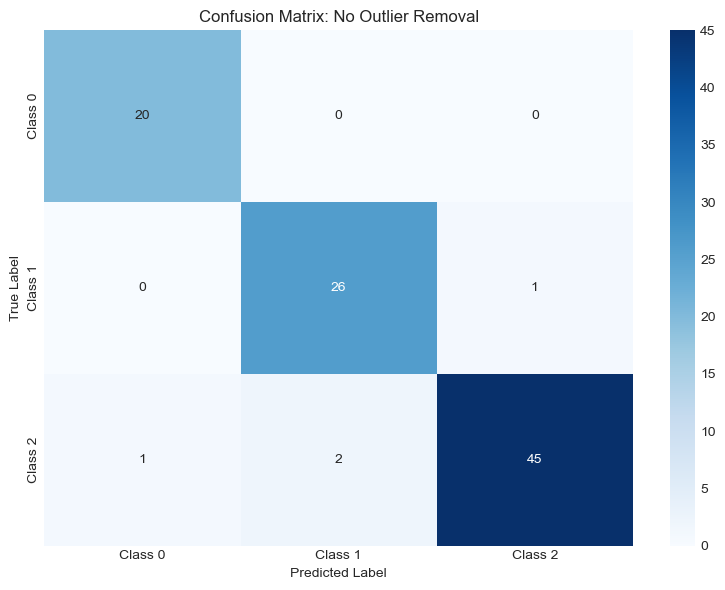

In [17]:
print(f"\n{'#'*60}")
print(f"Experiment 3-1: No Outlier Removal (Baseline)")
print(f"{'#'*60}")

# Use existing data
X_train_e3 = X_train_scaled
X_test_e3 = X_test_scaled
y_train_e3 = y_train
y_test_e3 = y_test

print(f"Training samples: {len(X_train_e3)}")
print(f"Test samples: {len(X_test_e3)}")
print(f"Infection rate range: [{y_train_e3.min():.2f}, {y_train_e3.max():.2f}]")

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_e3)
test_labels = kmeans.predict(X_test_e3)

analyze_clusters(y_train_e3.values, train_labels, "No Outlier Removal")
sil_score = silhouette_score(X_train_e3, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_e3, X_test_e3, 
    train_labels, test_labels,
    model_name="E3-1: No Outlier Removal"
)
results['silhouette_score'] = sil_score
results['outlier_method'] = 'None'
results['samples_removed'] = 0

print_results(results)
exp3_results.append(results)

class_names = [f"Class {i}" for i in range(3)]
plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: No Outlier Removal")

### E3-2: IQR Method


############################################################
Experiment 3-2: IQR Method
############################################################
Q1: 1.08
Q3: 7.50
IQR: 6.42
Upper bound: 17.14

Original samples: 473
Samples removed: 46 (9.73%)
Remaining samples: 427 (90.27%)
New infection rate range: [0.00, 17.02]

------------------------------------------------------------
Cluster Analysis: IQR Method
------------------------------------------------------------

Class Distribution:
  Class 0: 142 samples (41.64%)
  Class 1: 147 samples (43.11%)
  Class 2: 52 samples (15.25%)

Infection Rate Statistics per Class:
  Class 0: Mean=5.88, Std=4.94, Range=[0.26, 17.02]
  Class 1: Mean=1.75, Std=2.45, Range=[0.00, 16.50]
  Class 2: Mean=4.93, Std=4.27, Range=[0.30, 16.28]
------------------------------------------------------------

Silhouette Score: 0.2539

Model: E3-2: IQR Method
Test Accuracy:      94.19%
Balanced Accuracy:  89.76%
F1-Score (macro):   92.25%
CV Mean Accuracy:   93.56

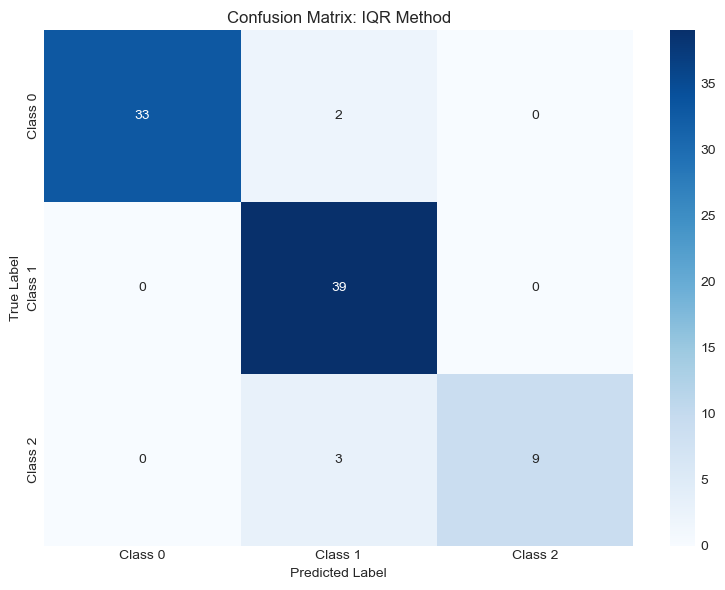

In [18]:
print(f"\n{'#'*60}")
print(f"Experiment 3-2: IQR Method")
print(f"{'#'*60}")

# Calculate IQR on full dataset
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Remove outliers
mask = y <= upper_bound
X_filtered = X[mask]
y_filtered = y[mask]

print(f"\nOriginal samples: {len(y)}")
print(f"Samples removed: {(~mask).sum()} ({(~mask).sum()/len(y)*100:.2f}%)")
print(f"Remaining samples: {len(y_filtered)} ({len(y_filtered)/len(y)*100:.2f}%)")
print(f"New infection rate range: [{y_filtered.min():.2f}, {y_filtered.max():.2f}]")

# New train-test split
X_train_e3, X_test_e3, y_train_e3, y_test_e3 = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Scale
scaler_e3 = StandardScaler()
X_train_e3 = scaler_e3.fit_transform(X_train_e3)
X_test_e3 = scaler_e3.transform(X_test_e3)

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_e3)
test_labels = kmeans.predict(X_test_e3)

analyze_clusters(y_train_e3.values, train_labels, "IQR Method")
sil_score = silhouette_score(X_train_e3, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_e3, X_test_e3, 
    train_labels, test_labels,
    model_name="E3-2: IQR Method"
)
results['silhouette_score'] = sil_score
results['outlier_method'] = 'IQR'
results['samples_removed'] = (~mask).sum()

print_results(results)
exp3_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: IQR Method")

### E3-3: Z-score Method


############################################################
Experiment 3-3: Z-score Method
############################################################
Z-score threshold: 3

Original samples: 473
Samples removed: 6 (1.27%)
Remaining samples: 467 (98.73%)
New infection rate range: [0.00, 24.81]

------------------------------------------------------------
Cluster Analysis: Z-score Method
------------------------------------------------------------

Class Distribution:
  Class 0: 133 samples (35.66%)
  Class 1: 135 samples (36.19%)
  Class 2: 105 samples (28.15%)

Infection Rate Statistics per Class:
  Class 0: Mean=6.55, Std=5.69, Range=[0.26, 24.24]
  Class 1: Mean=5.01, Std=7.39, Range=[0.00, 24.63]
  Class 2: Mean=3.94, Std=4.67, Range=[0.14, 20.79]
------------------------------------------------------------

Silhouette Score: 0.2219

Model: E3-3: Z-score Method
Test Accuracy:      98.94%
Balanced Accuracy:  99.26%
F1-Score (macro):   99.00%
CV Mean Accuracy:   94.10%
CV Std:     

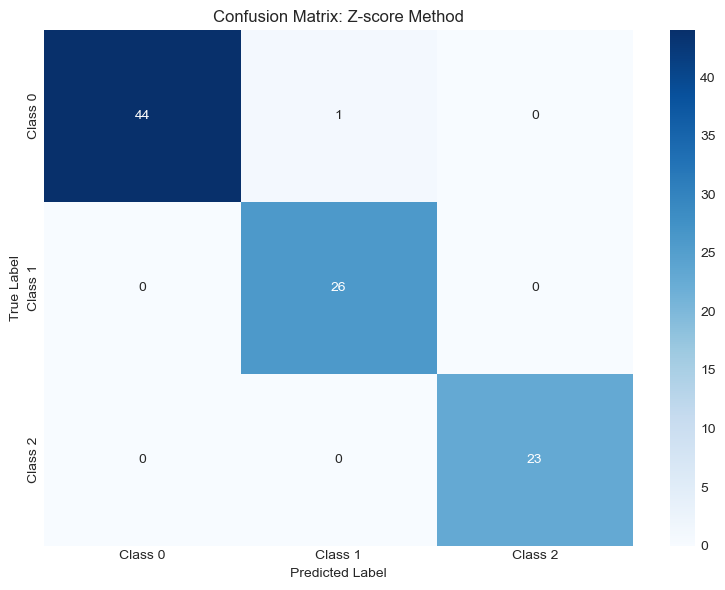

In [19]:
print(f"\n{'#'*60}")
print(f"Experiment 3-3: Z-score Method")
print(f"{'#'*60}")

# Calculate Z-scores
z_scores = np.abs((y - y.mean()) / y.std())
threshold = 3

print(f"Z-score threshold: {threshold}")

# Remove outliers
mask = z_scores <= threshold
X_filtered = X[mask]
y_filtered = y[mask]

print(f"\nOriginal samples: {len(y)}")
print(f"Samples removed: {(~mask).sum()} ({(~mask).sum()/len(y)*100:.2f}%)")
print(f"Remaining samples: {len(y_filtered)} ({len(y_filtered)/len(y)*100:.2f}%)")
print(f"New infection rate range: [{y_filtered.min():.2f}, {y_filtered.max():.2f}]")

# New train-test split
X_train_e3, X_test_e3, y_train_e3, y_test_e3 = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Scale
scaler_e3 = StandardScaler()
X_train_e3 = scaler_e3.fit_transform(X_train_e3)
X_test_e3 = scaler_e3.transform(X_test_e3)

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_e3)
test_labels = kmeans.predict(X_test_e3)

analyze_clusters(y_train_e3.values, train_labels, "Z-score Method")
sil_score = silhouette_score(X_train_e3, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_e3, X_test_e3, 
    train_labels, test_labels,
    model_name="E3-3: Z-score Method"
)
results['silhouette_score'] = sil_score
results['outlier_method'] = 'Z-score'
results['samples_removed'] = (~mask).sum()

print_results(results)
exp3_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: Z-score Method")

### E3-3-1 z-score outlier

In [25]:
import pandas as pd
import numpy as np

# 데이터 로드
df = pd.read_csv('../../data/processed/cleaned_disease_dataset_2015landuse.csv')

# Infection rate의 Z-score 계산
z_scores = np.abs((df['infection_rate'] - df['infection_rate'].mean()) / df['infection_rate'].std())
threshold = 3

# Outlier 식별
outlier_mask = z_scores > threshold
outliers = df[outlier_mask].copy()
outliers['z_score'] = z_scores[outlier_mask]

print("="*80)
print(f"Z-score Method로 제거된 Outliers ({len(outliers)}개)")
print("="*80)
print(f"\nZ-score threshold: {threshold}")
print(f"Infection rate mean: {df['infection_rate'].mean():.2f}")
print(f"Infection rate std: {df['infection_rate'].std():.2f}")
print(f"Upper bound (mean + 3*std): {df['infection_rate'].mean() + 3*df['infection_rate'].std():.2f}")
print("\n" + "="*80)
print("제거된 샘플 상세 정보:")
print("="*80)

# 주요 컬럼만 선택해서 보기 좋게 출력
display_cols = ['year', 'country', 'admin', 'infection_rate', 'z_score', 
                'min_temperature', 'rate_landuse']
outliers_display = outliers[display_cols].sort_values('infection_rate', ascending=False)

for idx, row in outliers_display.iterrows():
    print(f"\nSample {idx}:")
    print(f"  Year: {row['year']}")
    print(f"  Country: {row['country']}")
    print(f"  Admin: {row['admin']}")
    print(f"  Infection Rate: {row['infection_rate']:.2f}")
    print(f"  Z-score: {row['z_score']:.2f}")
    print(f"  Min Temperature: {row['min_temperature']:.2f}")
    print(f"  Land Use Rate: {row['rate_landuse']:.4f}")
    print(f"  {'-'*40}")

print("\n" + "="*80)
print("Outliers 통계:")
print("="*80)
print(f"Infection Rate 범위: [{outliers['infection_rate'].min():.2f}, {outliers['infection_rate'].max():.2f}]")
print(f"평균: {outliers['infection_rate'].mean():.2f}")
print(f"중앙값: {outliers['infection_rate'].median():.2f}")

# 국가별 분포
print("\n국가별 분포:")
print(outliers['country'].value_counts())

# 연도별 분포
print("\n연도별 분포:")
print(outliers['year'].value_counts().sort_index())

# 전체 데이터에서 제거된 비율
print(f"\n전체 {len(df)}개 샘플 중 {len(outliers)}개 제거 ({len(outliers)/len(df)*100:.2f}%)")

Z-score Method로 제거된 Outliers (6개)

Z-score threshold: 3
Infection rate mean: 5.42
Infection rate std: 6.60
Upper bound (mean + 3*std): 25.22

제거된 샘플 상세 정보:

Sample 222:
  Year: 2009
  Country: Lesotho
  Admin: Maseru
  Infection Rate: 27.07
  Z-score: 3.28
  Min Temperature: 277.53
  Land Use Rate: 0.1495
  ----------------------------------------

Sample 212:
  Year: 2014
  Country: Lesotho
  Admin: Maseru
  Infection Rate: 27.04
  Z-score: 3.28
  Min Temperature: 278.70
  Land Use Rate: 0.1495
  ----------------------------------------

Sample 403:
  Year: 2016
  Country: South Africa
  Admin: KwaZulu-Natal
  Infection Rate: 26.89
  Z-score: 3.25
  Min Temperature: 288.40
  Land Use Rate: 0.1787
  ----------------------------------------

Sample 210:
  Year: 2014
  Country: Lesotho
  Admin: Leribe
  Infection Rate: 26.05
  Z-score: 3.13
  Min Temperature: 279.53
  Land Use Rate: 0.1925
  ----------------------------------------

Sample 208:
  Year: 2014
  Country: Lesotho
  Admin: Be

### E3-4: Percentile-based (95th)


############################################################
Experiment 3-4: Percentile-based (95th)
############################################################
95th percentile: 20.85

Original samples: 473
Samples removed: 24 (5.07%)
Remaining samples: 449 (94.93%)
New infection rate range: [0.00, 20.79]

------------------------------------------------------------
Cluster Analysis: Percentile-based (95th)
------------------------------------------------------------

Class Distribution:
  Class 0: 90 samples (25.07%)
  Class 1: 153 samples (42.62%)
  Class 2: 116 samples (32.31%)

Infection Rate Statistics per Class:
  Class 0: Mean=4.06, Std=4.91, Range=[0.14, 20.79]
  Class 1: Mean=3.15, Std=4.50, Range=[0.00, 20.00]
  Class 2: Mean=6.39, Std=5.60, Range=[0.26, 20.08]
------------------------------------------------------------

Silhouette Score: 0.2167

Model: E3-4: Percentile-based (95th)
Test Accuracy:      94.44%
Balanced Accuracy:  94.63%
F1-Score (macro):   94.85%
CV Mean Ac

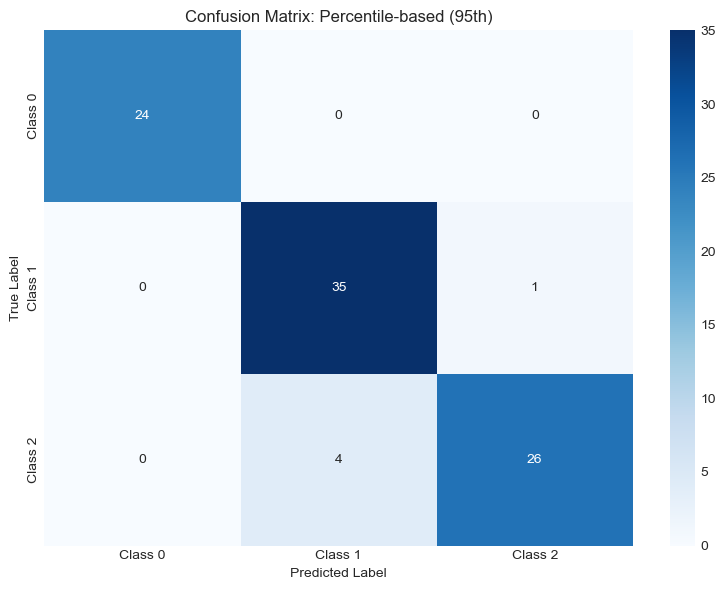

In [20]:
print(f"\n{'#'*60}")
print(f"Experiment 3-4: Percentile-based (95th)")
print(f"{'#'*60}")

# Calculate 95th percentile
p95 = y.quantile(0.95)
print(f"95th percentile: {p95:.2f}")

# Remove outliers
mask = y <= p95
X_filtered = X[mask]
y_filtered = y[mask]

print(f"\nOriginal samples: {len(y)}")
print(f"Samples removed: {(~mask).sum()} ({(~mask).sum()/len(y)*100:.2f}%)")
print(f"Remaining samples: {len(y_filtered)} ({len(y_filtered)/len(y)*100:.2f}%)")
print(f"New infection rate range: [{y_filtered.min():.2f}, {y_filtered.max():.2f}]")

# New train-test split
X_train_e3, X_test_e3, y_train_e3, y_test_e3 = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Scale
scaler_e3 = StandardScaler()
X_train_e3 = scaler_e3.fit_transform(X_train_e3)
X_test_e3 = scaler_e3.transform(X_test_e3)

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_e3)
test_labels = kmeans.predict(X_test_e3)

analyze_clusters(y_train_e3.values, train_labels, "Percentile-based (95th)")
sil_score = silhouette_score(X_train_e3, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_e3, X_test_e3, 
    train_labels, test_labels,
    model_name="E3-4: Percentile-based (95th)"
)
results['silhouette_score'] = sil_score
results['outlier_method'] = 'Percentile-95'
results['samples_removed'] = (~mask).sum()

print_results(results)
exp3_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: Percentile-based (95th)")

### E3-5: Domain-based (infection_rate > 20)


############################################################
Experiment 3-5: Domain-based (infection_rate > 20)
############################################################
Threshold: infection_rate > 20

Original samples: 473
Samples removed: 27 (5.71%)
Remaining samples: 446 (94.29%)
New infection rate range: [0.00, 20.00]

------------------------------------------------------------
Cluster Analysis: Domain-based (>20)
------------------------------------------------------------

Class Distribution:
  Class 0: 128 samples (35.96%)
  Class 1: 92 samples (25.84%)
  Class 2: 136 samples (38.20%)

Infection Rate Statistics per Class:
  Class 0: Mean=2.61, Std=4.34, Range=[0.00, 20.00]
  Class 1: Mean=3.49, Std=4.11, Range=[0.22, 18.75]
  Class 2: Mean=6.48, Std=5.42, Range=[0.26, 19.22]
------------------------------------------------------------

Silhouette Score: 0.2292

Model: E3-5: Domain-based (>20)
Test Accuracy:      98.89%
Balanced Accuracy:  99.17%
F1-Score (macro):   98.84%
C

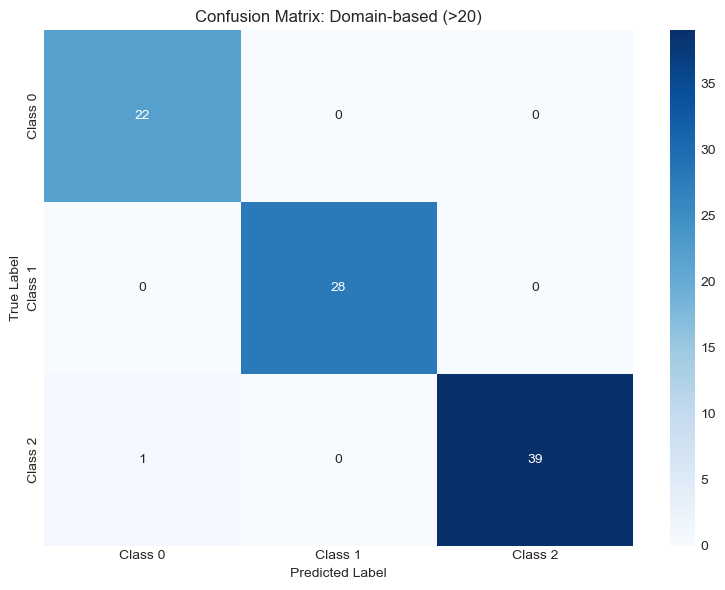

In [21]:
print(f"\n{'#'*60}")
print(f"Experiment 3-5: Domain-based (infection_rate > 20)")
print(f"{'#'*60}")

# Remove extreme outliers
threshold = 20
print(f"Threshold: infection_rate > {threshold}")

mask = y <= threshold
X_filtered = X[mask]
y_filtered = y[mask]

print(f"\nOriginal samples: {len(y)}")
print(f"Samples removed: {(~mask).sum()} ({(~mask).sum()/len(y)*100:.2f}%)")
print(f"Remaining samples: {len(y_filtered)} ({len(y_filtered)/len(y)*100:.2f}%)")
print(f"New infection rate range: [{y_filtered.min():.2f}, {y_filtered.max():.2f}]")

# New train-test split
X_train_e3, X_test_e3, y_train_e3, y_test_e3 = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Scale
scaler_e3 = StandardScaler()
X_train_e3 = scaler_e3.fit_transform(X_train_e3)
X_test_e3 = scaler_e3.transform(X_test_e3)

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_e3)
test_labels = kmeans.predict(X_test_e3)

analyze_clusters(y_train_e3.values, train_labels, "Domain-based (>20)")
sil_score = silhouette_score(X_train_e3, train_labels)
print(f"Silhouette Score: {sil_score:.4f}")

results = evaluate_lda_model(
    X_train_e3, X_test_e3, 
    train_labels, test_labels,
    model_name="E3-5: Domain-based (>20)"
)
results['silhouette_score'] = sil_score
results['outlier_method'] = 'Domain-based'
results['samples_removed'] = (~mask).sum()

print_results(results)
exp3_results.append(results)

plot_confusion_matrix(results['confusion_matrix'], class_names, 
                     "Confusion Matrix: Domain-based (>20)")

## Experiment 3: Results Summary

In [22]:
# Create summary dataframe
exp3_summary = pd.DataFrame([
    {
        'Method': r['outlier_method'],
        'Removed': r['samples_removed'],
        'Test Acc (%)': f"{r['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{r['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{r['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{r['cv_mean']*100:.2f}",
        'CV Std (%)': f"{r['cv_std']*100:.2f}",
        'Silhouette': f"{r['silhouette_score']:.4f}"
    }
    for r in exp3_results
])

print("\nExperiment 3 Summary: Outlier Removal Strategies (K-means k=3)")
print("="*100)
print(exp3_summary.to_string(index=False))
print("="*100)


Experiment 3 Summary: Outlier Removal Strategies (K-means k=3)
       Method  Removed Test Acc (%) Balanced Acc (%) F1-macro (%) CV Mean (%) CV Std (%) Silhouette
         None        0        95.79            96.68        95.95       95.77       2.93     0.2607
          IQR       46        94.19            89.76        92.25       93.56       3.40     0.2539
      Z-score        6        98.94            99.26        99.00       94.10       2.61     0.2219
Percentile-95       24        94.44            94.63        94.85       95.81       2.52     0.2167
 Domain-based       27        98.89            99.17        98.84       95.52       3.44     0.2292


## Overall Comparison with Baseline

In [23]:
# Baseline results from previous LDA with Q1-Q4 classification
baseline = {
    'Model': 'Baseline (Q1-Q4)',
    'Test Acc (%)': '56.84',
    'Balanced Acc (%)': '57.16',
    'F1-macro (%)': '55.81',
    'CV Mean (%)': '57.68',
    'CV Std (%)': '6.58'
}

# Find best results from each experiment
best_exp1 = max(exp1_results, key=lambda x: x['balanced_acc'])
best_exp2 = max(exp2_results, key=lambda x: x['balanced_acc'])
best_exp3 = max(exp3_results, key=lambda x: x['balanced_acc'])

comparison_data = [
    baseline,
    {
        'Model': f"Best Exp1 (k={best_exp1['k']})",
        'Test Acc (%)': f"{best_exp1['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{best_exp1['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{best_exp1['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{best_exp1['cv_mean']*100:.2f}",
        'CV Std (%)': f"{best_exp1['cv_std']*100:.2f}"
    },
    {
        'Model': f"Best Exp2 ({best_exp2['method']})",
        'Test Acc (%)': f"{best_exp2['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{best_exp2['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{best_exp2['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{best_exp2['cv_mean']*100:.2f}",
        'CV Std (%)': f"{best_exp2['cv_std']*100:.2f}"
    },
    {
        'Model': f"Best Exp3 ({best_exp3['outlier_method']})",
        'Test Acc (%)': f"{best_exp3['test_acc']*100:.2f}",
        'Balanced Acc (%)': f"{best_exp3['balanced_acc']*100:.2f}",
        'F1-macro (%)': f"{best_exp3['f1_macro']*100:.2f}",
        'CV Mean (%)': f"{best_exp3['cv_mean']*100:.2f}",
        'CV Std (%)': f"{best_exp3['cv_std']*100:.2f}"
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*90)
print("OVERALL COMPARISON WITH BASELINE")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)


OVERALL COMPARISON WITH BASELINE
              Model Test Acc (%) Balanced Acc (%) F1-macro (%) CV Mean (%) CV Std (%)
   Baseline (Q1-Q4)        56.84            57.16        55.81       57.68       6.58
    Best Exp1 (k=3)        95.79            96.68        95.95       95.77       2.93
Best Exp2 (K-means)        95.79            96.68        95.95       95.77       2.93
Best Exp3 (Z-score)        98.94            99.26        99.00       94.10       2.61
